# Isoborneol Eu(fod)₃ titration: deriving model input shifts

This notebook converts assigned $^1$H NMR chemical shifts from an Eu(fod)₃ titration into the relative experimental shifts required by EuFOD. It keeps the raw data, calculated $\Delta\delta$ values, and normalization choice visible and reproducible.

For each proton and Eu(fod)₃ mass, the induced shift is:

$$\Delta\delta_i(m) = \delta_i(m) - \delta_i(0)$$

The EuFOD input uses relative shifts, normalized to a selected reference proton:

$$\Delta\delta_{\mathrm{rel},i} = \frac{\Delta\delta_i(m)}{\Delta\delta_{\mathrm{reference}}(m)}$$


In [12]:
import pandas as pd

# Eu(fod)3 mass added to the NMR sample, in mg.
eufod_mg = [0.0, 5.0, 11.3, 17.3, 25.7, 35.3]

# Assigned 1H chemical shifts (ppm) for isoborneol.
# Rows are proton designations; columns follow the masses above.
raw_shifts = pd.DataFrame(
    [
        [3.62, 4.48, 5.94, 7.19, 8.95, 10.89],
        [1.73, 2.39, 3.47, 4.40, 5.69, 7.10],
        [1.73, 2.02, 2.53, 2.97, 3.62, 4.27],
        [1.71, 1.92, 2.28, 2.59, 3.04, 3.49],
        [1.67, 1.81, 2.03, 2.26, 2.57, 2.85],
        [1.00, 1.17, 1.42, 1.64, 1.96, 2.29],
        [1.50, 1.65, 1.88, 2.10, 2.41, 2.75],
        [0.98, 1.17, 1.54, 1.86, 2.33, 2.75],
        [0.82, 1.00, 1.29, 1.54, 1.91, 2.28],
        [1.02, 1.41, 2.08, 2.66, 3.47, 4.32],
        [0.90, 1.34, 2.07, 2.69, 3.57, 4.49],
    ],
    index=[
        'H-2', 'H-3exo', 'H-3endo', 'H-4', 'H-5exo', 'H-5endo',
        'H-6exo', 'H-6endo', '8CH3', '9CH3', '10CH3',
    ],
    columns=eufod_mg,
)
raw_shifts.index.name = 'Proton'
raw_shifts.columns.name = 'Eu(fod)3 added (mg)'
raw_shifts


Eu(fod)3 added (mg),0.0,5.0,11.3,17.3,25.7,35.3
Proton,,,,,,
H-2,3.62,4.48,5.94,7.19,8.95,10.89
H-3exo,1.73,2.39,3.47,4.40,5.69,7.10
H-3endo,1.73,2.02,2.53,2.97,3.62,4.27
H-4,1.71,1.92,2.28,2.59,3.04,3.49
H-5exo,1.67,1.81,2.03,2.26,2.57,2.85
H-5endo,1.00,1.17,1.42,1.64,1.96,2.29
H-6exo,1.50,1.65,1.88,2.10,2.41,2.75
H-6endo,0.98,1.17,1.54,1.86,2.33,2.75
8CH3,0.82,1.00,1.29,1.54,1.91,2.28


## Calibration curves

Each panel shows the observed chemical shift against the added Eu(fod)₃ mass. The solid line is an ordinary least-squares fit; $R^2$ summarizes how closely the measured titration points follow a linear response over this range.

,Slope (ppm/mg),Intercept (ppm),R²
Proton,,,
H-2,0.2085,3.557,0.9994
H-3exo,0.1539,1.703,0.9994
H-3endo,0.0733,1.700,0.9990
H-4,0.0514,1.695,0.9990
H-5exo,0.0343,1.657,0.9979
H-5endo,0.0369,0.998,0.9996
H-6exo,0.0358,1.483,0.9995
H-6endo,0.0517,0.957,0.9976
8CH3,0.0420,0.811,0.9993


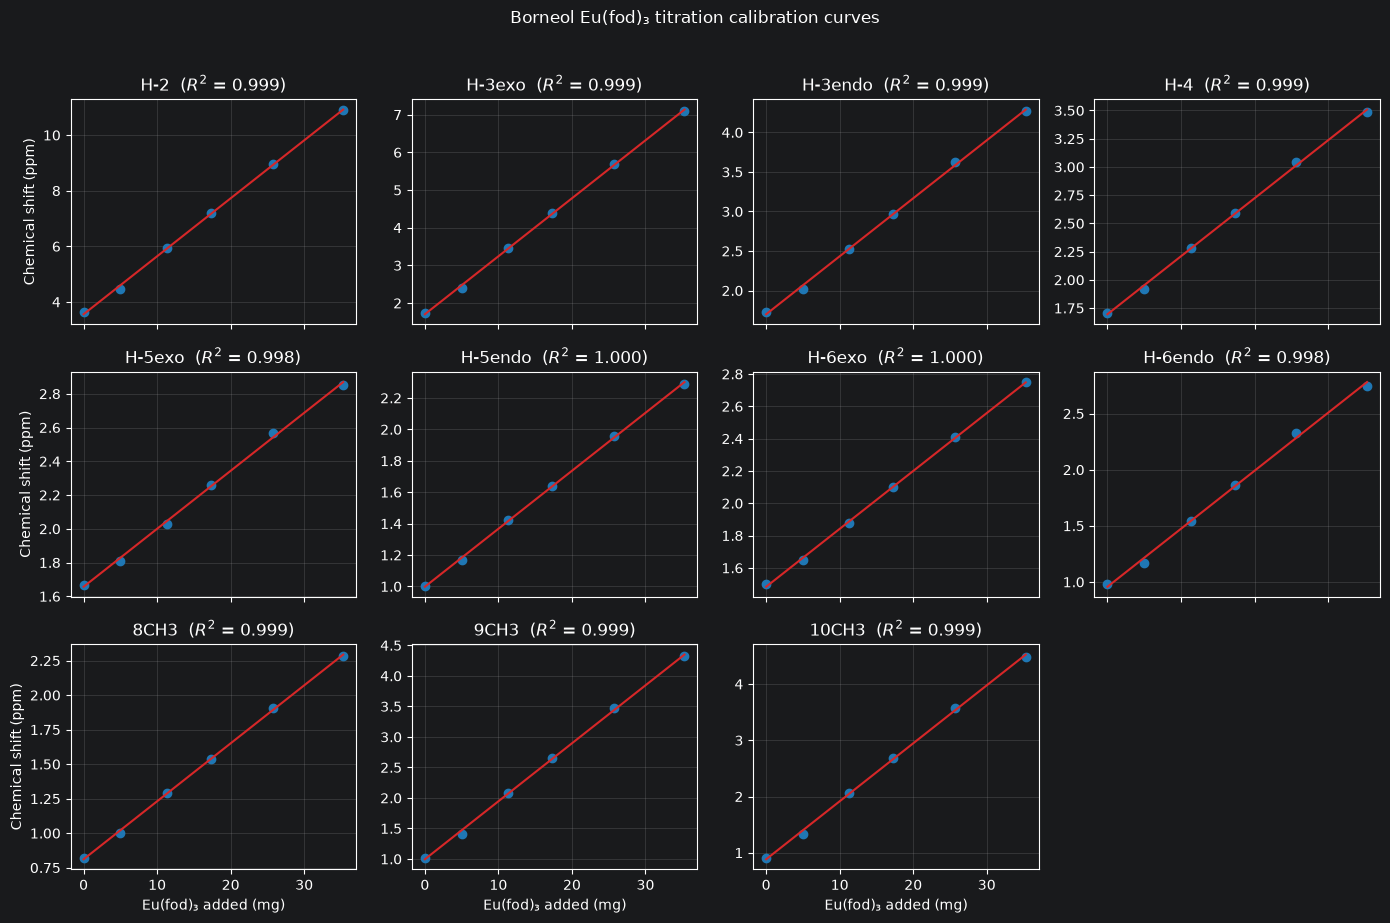

In [13]:
import matplotlib.pyplot as plt
import numpy as np

mass = raw_shifts.columns.to_numpy(dtype=float)
fit_rows = []
fig, axes = plt.subplots(3, 4, figsize=(14, 9), sharex=True)

for axis, (proton, shifts) in zip(axes.flat, raw_shifts.iterrows()):
    observed = shifts.to_numpy(dtype=float)
    slope, intercept = np.polyfit(mass, observed, deg=1)
    fitted = slope * mass + intercept
    residual_sum_squares = np.sum((observed - fitted) ** 2)
    total_sum_squares = np.sum((observed - observed.mean()) ** 2)
    r_squared = 1 - residual_sum_squares / total_sum_squares

    axis.scatter(mass, observed, color='#1f77b4', zorder=2)
    axis.plot(mass, fitted, color='#d62728', linewidth=1.5)
    axis.set_title(f'{proton}  ($R^2$ = {r_squared:.3f})')
    axis.grid(alpha=0.25)

    fit_rows.append(
        {
            'Proton': proton,
            'Slope (ppm/mg)': slope,
            'Intercept (ppm)': intercept,
            'R²': r_squared,
        }
    )

for axis in axes[-1, :]:
    axis.set_xlabel('Eu(fod)₃ added (mg)')
for axis in axes[:, 0]:
    axis.set_ylabel('Chemical shift (ppm)')
axes.flat[-1].set_visible(False)
fig.suptitle('Borneol Eu(fod)₃ titration calibration curves', y=1.02)
fig.tight_layout()

calibration_summary = pd.DataFrame(fit_rows).set_index('Proton')
calibration_summary.style.format(
    {'Slope (ppm/mg)': '{:.4f}', 'Intercept (ppm)': '{:.3f}', 'R²': '{:.4f}'}
)

In [14]:
# Subtract the no-Eu(fod)3 chemical shift from every titration point.
delta_shifts = raw_shifts.subtract(raw_shifts[0.0], axis='index')
delta_shifts = delta_shifts.drop(columns=0.0)
delta_shifts.columns.name = 'Eu(fod)3 added (mg)'
delta_shifts.style.format('{:.2f}')

Eu(fod)3 added (mg),5.000000,11.300000,17.300000,25.700000,35.300000
Proton,,,,,
H-2,0.86,2.32,3.57,5.33,7.27
H-3exo,0.66,1.74,2.67,3.96,5.37
H-3endo,0.29,0.80,1.24,1.89,2.54
H-4,0.21,0.57,0.88,1.33,1.78
H-5exo,0.14,0.36,0.59,0.90,1.18
H-5endo,0.17,0.42,0.64,0.96,1.29
H-6exo,0.15,0.38,0.60,0.91,1.25
H-6endo,0.19,0.56,0.88,1.35,1.77
8CH3,0.18,0.47,0.72,1.09,1.46


## Select the titration point and normalization reference

Change these two values to prepare input for another Eu(fod)₃ amount or reference assignment. The selected reference must have a nonzero $\Delta\delta$ at the selected titration point. In the EuFOD model, place this reference proton first in the input file.

In [15]:
selected_eufod_mg = 35.3
reference_proton = 'H-2'

if selected_eufod_mg not in delta_shifts.columns:
    raise ValueError(f'No titration data are available for {selected_eufod_mg} mg.')

selected_delta = delta_shifts[selected_eufod_mg]
reference_delta = selected_delta[reference_proton]
if reference_delta == 0:
    raise ValueError('The reference proton has a zero Δδ and cannot normalize the data.')

relative_shifts = selected_delta / reference_delta
input_shifts = pd.DataFrame(
    {
        'Label': relative_shifts.index,
        'Δδexp (ppm)': selected_delta.values,
        'Relative exp. shift': relative_shifts.values,
    }
)

# Put the normalization reference first, as required by the current model.
input_shifts = pd.concat(
    [
        input_shifts[input_shifts['Label'] == reference_proton],
        input_shifts[input_shifts['Label'] != reference_proton],
    ],
    ignore_index=True,
)
input_shifts.style.format({'Δδexp (ppm)': '{:.3f}', 'Relative exp. shift': '{:.3f}'})

,Label,Δδexp (ppm),Relative exp. shift
0,H-2,7.270,1.000
1,H-3exo,5.370,0.739
2,H-3endo,2.540,0.349
3,H-4,1.780,0.245
4,H-5exo,1.180,0.162
5,H-5endo,1.290,0.177
6,H-6exo,1.250,0.172
7,H-6endo,1.770,0.243
8,8CH3,1.460,0.201
9,9CH3,3.300,0.454


## Generate a minimized isoborneol geometry

This step uses the stereochemical isoborneol SMILES supplied for this study. RDKit adds explicit hydrogens, generates an ensemble of 3D conformers, optimizes every conformer with MMFF94, and selects the lowest-energy conformer that converged. The resulting coordinates are reported in cÅ.


In [16]:
# Fill these from the isoborneol coordinate model (cÅ).
oxygen_coordinates = ('X_O', 'Y_O', 'Z_O')
hydrogen_coordinates = {
    # 'H-2': ('X', 'Y', 'Z'),
    # 'H-3exo': ('X', 'Y', 'Z'),
}

print('# Coordinate unit: cÅ')
print('# Oxygen Center')
print('O   ' + '  '.join(map(str, oxygen_coordinates)))
print('\n# Proton Assignments (Label, Exp_Shift, X, Y, Z)')
for label, relative_shift in zip(
    input_shifts['Label'],
    input_shifts['Relative exp. shift'],
):
    coordinates = hydrogen_coordinates.get(label, ('X', 'Y', 'Z'))
    print(f'{label:<8} {relative_shift:.6f}  ' + '  '.join(map(str, coordinates)))


# Coordinate unit: cÅ
# Oxygen Center
O   X_O  Y_O  Z_O

# Proton Assignments (Label, Exp_Shift, X, Y, Z)
H-2      1.000000  X  Y  Z
H-3exo   0.738652  X  Y  Z
H-3endo  0.349381  X  Y  Z
H-4      0.244842  X  Y  Z
H-5exo   0.162311  X  Y  Z
H-5endo  0.177442  X  Y  Z
H-6exo   0.171939  X  Y  Z
H-6endo  0.243466  X  Y  Z
8CH3     0.200825  X  Y  Z
9CH3     0.453920  X  Y  Z
10CH3    0.493810  X  Y  Z


In [17]:
from rdkit import Chem
from rdkit.Chem import AllChem

isoborneol_smiles = 'C[C@@]12CC[C@@H](C1(C)C)C[C@H]2O'
isoborneol = Chem.MolFromSmiles(isoborneol_smiles)
if isoborneol is None:
    raise ValueError('The isoborneol SMILES could not be parsed.')

isoborneol = Chem.AddHs(isoborneol)
if not AllChem.MMFFHasAllMoleculeParams(isoborneol):
    raise ValueError('MMFF94 parameters are unavailable for this molecule.')

embedding_parameters = AllChem.ETKDGv3()
embedding_parameters.randomSeed = 20260905
embedding_parameters.useSmallRingTorsions = True
conformer_ids = list(
    AllChem.EmbedMultipleConfs(
        isoborneol,
        numConfs=20,
        params=embedding_parameters,
    )
)
if not conformer_ids:
    raise RuntimeError('RDKit could not generate a 3D conformer.')

optimization_results = AllChem.MMFFOptimizeMoleculeConfs(
    isoborneol,
    numThreads=1,
    maxIters=1000,
    mmffVariant='MMFF94',
)
conformer_summary = pd.DataFrame(
    [
        {
            'Conformer': conformer_id,
            'Converged': not not_converged,
            'MMFF94 energy (kcal/mol)': energy,
        }
        for conformer_id, (not_converged, energy) in zip(
            conformer_ids,
            optimization_results,
        )
    ]
).sort_values('MMFF94 energy (kcal/mol)', ignore_index=True)

converged_conformers = conformer_summary[conformer_summary['Converged']]
if converged_conformers.empty:
    raise RuntimeError('No MMFF94 conformer converged.')

best_conformer_id = int(converged_conformers.iloc[0]['Conformer'])
best_conformer = isoborneol.GetConformer(best_conformer_id)
conformer_summary.head(10)


,Conformer,Converged,MMFF94 energy (kcal/mol)
0,2,True,55.431044
1,3,True,55.431044
2,14,True,55.431044
3,18,True,55.431044
4,19,True,55.431044
5,5,True,55.431044
6,6,True,55.431044
7,0,True,55.431044
8,9,True,55.431044
9,17,True,55.431044


## Optimized 3D conformer

This interactive view uses the selected lowest-energy MMFF94 conformer. Oxygen is highlighted in red. Every atom is labeled as `index: element`, matching the Coordinate table below; rotate and zoom to inspect crowded hydrogen labels.

In [18]:
import py3Dmol

molecule_block = Chem.MolToMolBlock(isoborneol, confId=best_conformer_id)
viewer = py3Dmol.view(width=700, height=500)
viewer.addModel(molecule_block, 'mol')
viewer.setStyle({'stick': {'radius': 0.12}})
viewer.addStyle({'elem': 'O'}, {'sphere': {'radius': 0.28, 'color': 'red'}})
for atom in isoborneol.GetAtoms():
    position = best_conformer.GetAtomPosition(atom.GetIdx())
    viewer.addLabel(
        f'{atom.GetIdx()}: {atom.GetSymbol()}',
        {
            'position': {'x': position.x, 'y': position.y, 'z': position.z},
            'fontSize': 10,
            'backgroundColor': 'white',
            'fontColor': 'black',
            'backgroundOpacity': 0.65,
        },
    )
viewer.zoomTo()
viewer.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Coordinate table and proton mapping

The table below reports every explicit atom in the selected geometry. `Atom index` is the RDKit index needed in the mapping cell. The `Attached to` column identifies the heavy atom bonded to each explicit H. Verify the exo/endo and methyl assignments against your molecular numbering before using the output.

In [19]:
def coordinates_in_cangstrom(position):
    return tuple(round(value * 100) for value in (position.x, position.y, position.z))

coordinate_rows = []
coordinates_by_atom = {}
for atom in isoborneol.GetAtoms():
    atom_index = atom.GetIdx()
    coordinates = coordinates_in_cangstrom(
        best_conformer.GetAtomPosition(atom_index)
    )
    coordinates_by_atom[atom_index] = coordinates
    coordinate_rows.append(
        {
            'Atom index': atom_index,
            'Element': atom.GetSymbol(),
            'Attached to': ', '.join(
                str(neighbor.GetIdx()) for neighbor in atom.GetNeighbors()
            ),
            'X (cÅ)': coordinates[0],
            'Y (cÅ)': coordinates[1],
            'Z (cÅ)': coordinates[2],
        }
    )

coordinate_table = pd.DataFrame(coordinate_rows)
coordinate_table

,Atom index,Element,Attached to,X (cÅ),Y (cÅ),Z (cÅ)
0,0,C,"1, 11, 12, 13",37,-197,-97
1,1,C,"0, 2, 5, 9",-11,-82,-10
2,2,C,"1, 3, 14, 15",-2,-113,142
3,3,C,"2, 4, 16, 17",-11,26,206
4,4,C,"3, 5, 8, 18",-22,120,84
5,5,C,"4, 6, 7, 1",69,52,-22
6,6,C,"5, 19, 20, 21",66,121,-160
7,7,C,"5, 22, 23, 24",217,44,18
8,8,C,"4, 9, 25, 26",-165,102,26
9,9,C,"8, 10, 1, 27",-159,-40,-34


## Create coordinate-complete EuFOD input

Set the oxygen and assigned-hydrogen atom indices after checking the coordinate table and molecular numbering. The current EuFOD model accepts one coordinate per assignment. Therefore the methyl resonances (`8CH3`, `9CH3`, and `10CH3`) are excluded below: they represent rapidly averaged three-proton signals and should not be represented by an arbitrary single H coordinate. Supporting group-averaged methyl predictions is a separate model extension.

In [20]:
# The hydroxyl oxygen is atom 10 in the supplied SMILES.
oxygen_atom_index = 10

# Replace None with the explicit-H atom index for each NMR assignment.
# Use coordinate_table above to confirm every assignment, especially exo/endo H atoms.
proton_atom_indices = {
    'H-2': 27,
    'H-3exo': 26,
    'H-3endo': 25,
    'H-4': 18,
    'H-5exo': 17,
    'H-5endo': 16,
    'H-6exo': 15,
    'H-6endo': 14,
}

model_input_shifts = input_shifts[
    ~input_shifts['Label'].str.endswith('CH3')
].copy()
missing_assignments = [
    label for label in model_input_shifts['Label']
    if proton_atom_indices[label] is None
]

if missing_assignments:
    print('Assign explicit-H atom indices for: ' + ', '.join(missing_assignments))
else:
    print('# Coordinate unit: cÅ')
    print('# Oxygen Center')
    print('O   ' + '  '.join(map(str, coordinates_by_atom[oxygen_atom_index])))
    print('\n# Proton Assignments (Label, Exp_Shift, X, Y, Z)')
    for label, relative_shift in zip(
        model_input_shifts['Label'],
        model_input_shifts['Relative exp. shift'],
    ):
        coordinates = coordinates_by_atom[proton_atom_indices[label]]
        print(
            f'{label:<8} {relative_shift:.6f}  ' +
            '  '.join(map(str, coordinates))
        )


# Coordinate unit: cÅ
# Oxygen Center
O   -193  -38  -172

# Proton Assignments (Label, Exp_Shift, X, Y, Z)
H-2      1.000000  -229  -108  16
H-3exo   0.738652  -188  178  -48
H-3endo  0.349381  -241  108  105
H-4      0.244842  2  224  107
H-5exo   0.162311  79  48  265
H-5endo  0.177442  -97  35  273
H-6exo   0.171939  92  -162  169
H-6endo  0.243466  -83  -179  176


## R-factor cloud from Streamlit mapping output

This section reads the R-factor mapping exported by the Streamlit app; it does not rerun the EuFOD search. It retains the 1,000 lowest-R-factor positions and plots them around the MMFF94-optimized isoborneol conformer. The color scale reports each candidate's percentage increase in R-factor above the optimum: green is closest to the optimal fit and red is farther away.

In [25]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / 'outputs').exists():
    project_root = project_root.parent

mapping_path = project_root / 'outputs' / 'isoborneol_r_factor_mapping.txt'
if not mapping_path.exists():
    raise FileNotFoundError(f'Mapping file not found: {mapping_path}')

mapping_header = mapping_path.read_text(encoding='utf-8').splitlines()[:7]
if '# metric: r_factor' not in mapping_header:
    raise ValueError('This notebook requires an R-factor mapping export.')

mapping = pd.read_csv(
    mapping_path,
    sep='\t',
    comment='#',
    names=['Eu X (cÅ)', 'Eu Y (cÅ)', 'Eu Z (cÅ)', 'R-factor'],
)
top_n = 1_000
top_candidates = mapping.nsmallest(top_n, 'R-factor').copy()
optimal_r_factor = top_candidates['R-factor'].iloc[0]
top_candidates['R-factor above optimum (%)'] = 100 * (
    top_candidates['R-factor'] - optimal_r_factor
) / optimal_r_factor
top_candidates.insert(0, 'Rank', range(1, len(top_candidates) + 1))

print(f'Loaded {len(mapping):,} valid positions from {mapping_path.name}.')
print(f'Best R-factor: {optimal_r_factor:.6f}')
top_candidates.head(10)

Loaded 130,559 valid positions from isoborneol_r_factor_mapping.txt.
Best R-factor: 6.862366


,Rank,Eu X (cÅ),Eu Y (cÅ),Eu Z (cÅ),R-factor,R-factor above optimum (%)
32909,1,-403,-128,-292,6.862366,0.000000
32868,2,-403,-138,-292,6.885111,0.331445
35860,3,-393,-138,-292,6.924358,0.903369
29745,4,-413,-128,-292,6.939628,1.125885
35898,5,-393,-128,-292,6.953125,1.322570
35899,6,-393,-128,-282,6.998069,1.977497
29700,7,-413,-138,-292,7.009343,2.141782
35937,8,-393,-118,-282,7.089215,3.305703
32950,9,-403,-118,-292,7.090507,3.324529
29790,10,-413,-118,-292,7.101136,3.479408


In [26]:
# Interactive 3D cloud: the mapping uses cÅ, while the molecular model uses Å.
# Green spheres are closest to the best R-factor; red spheres are farther away.
def r_factor_colour(percent_above_optimum, maximum_percent):
    fraction = 0.0 if maximum_percent == 0 else percent_above_optimum / maximum_percent
    fraction = max(0.0, min(1.0, fraction))
    if fraction < 0.5:
        local_fraction = fraction * 2
        start, end = (44, 160, 44), (255, 192, 0)   # green to yellow
    else:
        local_fraction = (fraction - 0.5) * 2
        start, end = (255, 192, 0), (214, 39, 40)   # yellow to red
    return '#' + ''.join(
        f'{round(start[channel] + local_fraction * (end[channel] - start[channel])):02x}'
        for channel in range(3)
    )

maximum_percent = top_candidates['R-factor above optimum (%)'].max()
cloud_viewer = py3Dmol.view(width=850, height=650)
cloud_viewer.setBackgroundColor('white')
cloud_viewer.addModel(molecule_block, 'mol')
cloud_viewer.setStyle({'stick': {'radius': 0.08, 'color': '#707070'}})
cloud_viewer.addStyle({'elem': 'O'}, {'sphere': {'radius': 0.24, 'color': '#d62728'}})

for candidate in top_candidates.itertuples(index=False):
    cloud_viewer.addSphere({
        'center': {
            'x': getattr(candidate, '_1') / 100,
            'y': getattr(candidate, '_2') / 100,
            'z': getattr(candidate, '_3') / 100,
        },
        'radius': 0.075,
        'color': r_factor_colour(
            getattr(candidate, '_5'), maximum_percent
        ),
        'opacity': 0.60,
    })

best_candidate = top_candidates.iloc[0]
cloud_viewer.addSphere({
    'center': {
        'x': best_candidate['Eu X (cÅ)'] / 100,
        'y': best_candidate['Eu Y (cÅ)'] / 100,
        'z': best_candidate['Eu Z (cÅ)'] / 100,
    },
    'radius': 0.08,
    'color': '#00bcd4',
    'opacity': 1.0,
})
cloud_viewer.zoomTo()
cloud_viewer.show()

print(
    f'Top {len(top_candidates):,} positions shown as spheres. '
    f'Colour: green = best R; red = {maximum_percent:.1f}% above the optimum; '
    'cyan = best Eu position.'
)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Top 1,000 positions shown as spheres. Colour: green = best R; red = 49.8% above the optimum; cyan = best Eu position.
